In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Regular expressions
import re
# String operations
import string
# Natural Language Processing
import nltk
# NLTK resources 
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")
# NLTK preprocessing tools
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# Machine Learning Models (Baseline)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
# Save tokenizer and label encoder
import pickle
# Word Cloud
from wordcloud import WordCloud
import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pradh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\pradh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\pradh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\pradh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
df=pd.read_csv("C:/Users/pradh/OneDrive/Desktop/sentiment_analysis/DataSet/final_dataset.csv")
df

,text,emotion
0,i feel rather funny ending with so many dupes ...,fun
1,i feel surprised by the result,surprise
2,i am officially feeling festive,neutral
3,i suddenly found myself standing before this w...,surprise
4,i look at the meager pile of food i purchased ...,enthusiasm
...,...,...
106350,i used to feel strongly about how much i hated...,hate
106351,i feel like i just got a spirit booster this r...,surprise
106352,i could come up with is that i was really feel...,anger
106353,i find it really it helps to have an outfit of...,relief


In [3]:
df.shape

(106355, 2)

In [4]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

HANDLING DUPLICATES

In [5]:
df.duplicated().sum()

np.int64(25529)

In [6]:
df[df.duplicated()]

,text,emotion
480,i could talk myself tired and whatever i said ...,hate
482,i go to a blog i feel like i have something cl...,fun
485,i do hope god feels like giving to charity tod...,fun
655,i feel after i quit a job i hated reality,hate
1052,i feel so empty inside and its killing me,empty
...,...,...
106350,i used to feel strongly about how much i hated...,hate
106351,i feel like i just got a spirit booster this r...,surprise
106352,i could come up with is that i was really feel...,anger
106353,i find it really it helps to have an outfit of...,relief


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

# visualisation 

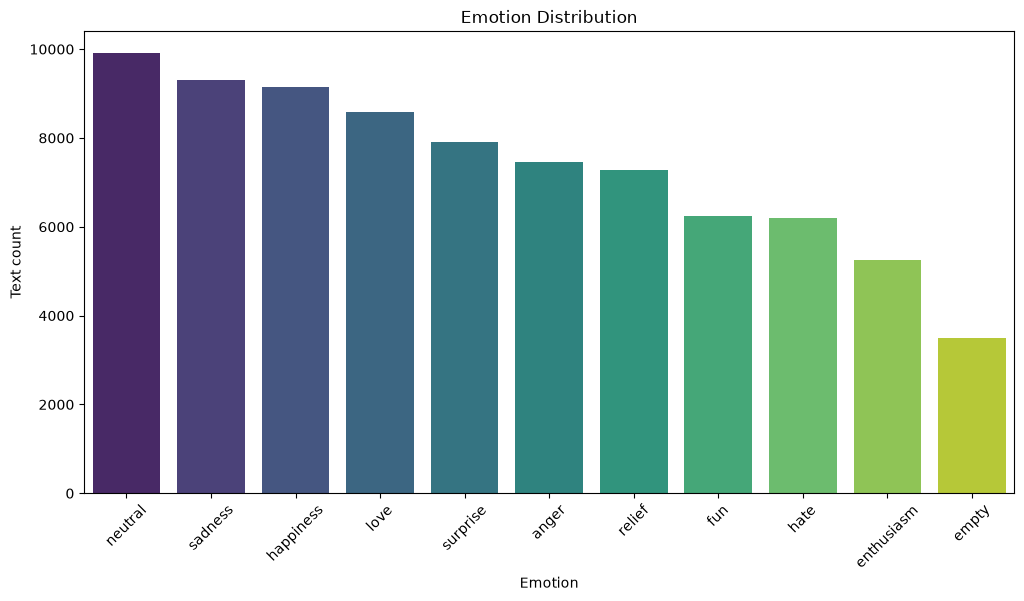

In [9]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="emotion",
    data=df,
    palette="viridis",
    order=df["emotion"].value_counts().index
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Text count")

plt.xticks(rotation=45)

plt.show()

In [10]:
df["text_length"] = df["text"].astype(str).apply(len)

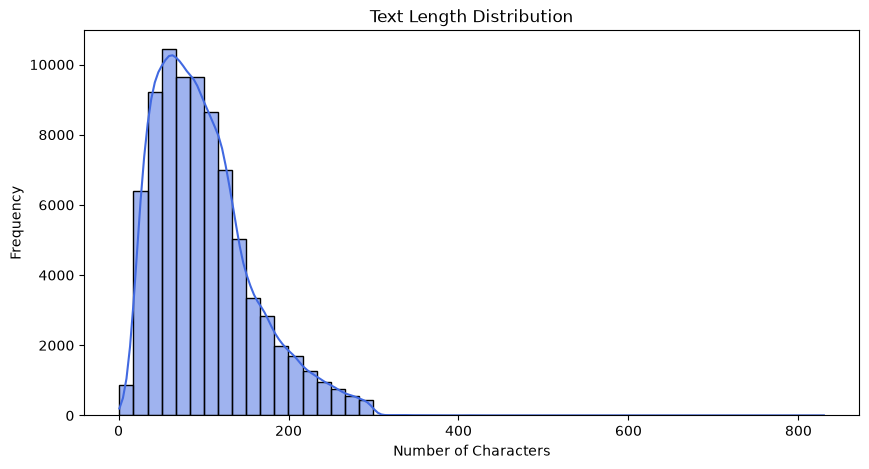

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(
    df["text_length"],
    bins=50,
    kde=True,
    color="royalblue"
)
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

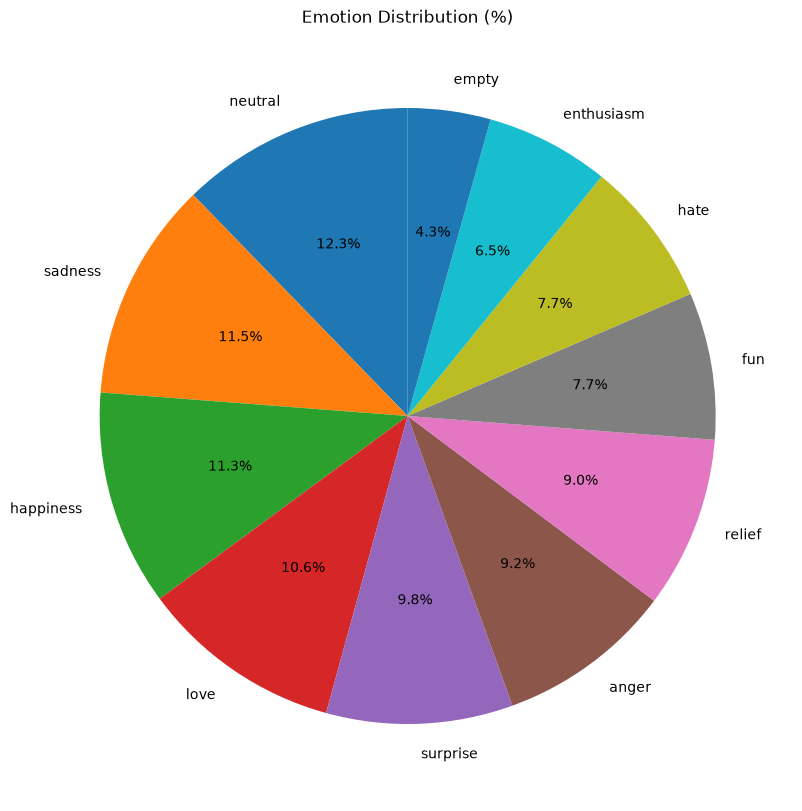

In [12]:
emotion_counts = df["emotion"].value_counts()
plt.figure(figsize=(10,10))
plt.pie(
    emotion_counts,
    labels=emotion_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Emotion Distribution (%)")
plt.show()

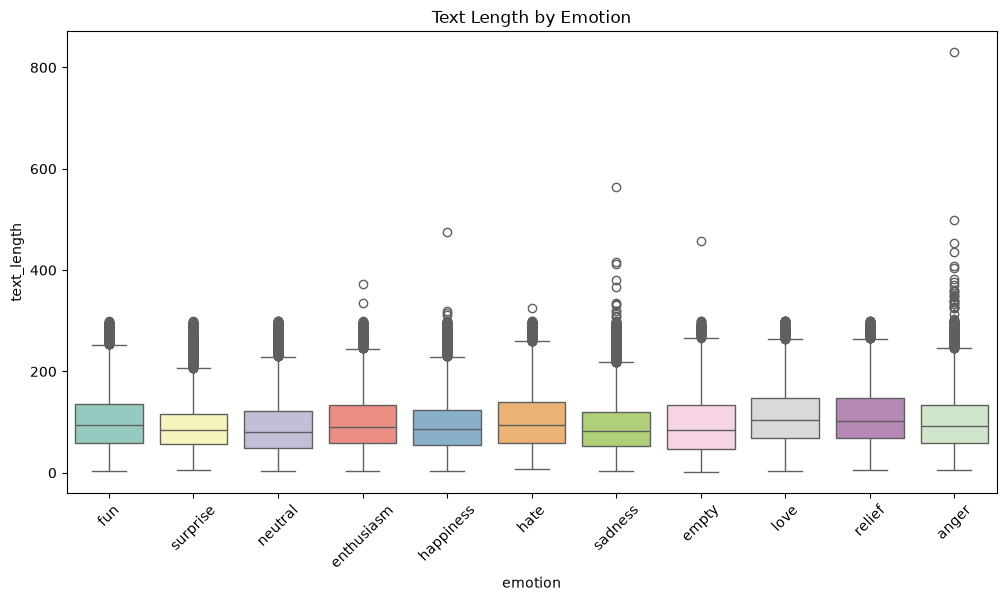

In [13]:
plt.figure(figsize=(12,6))
sns.boxplot(
    x="emotion",
    y="text_length",
    data=df,
    palette="Set3"
)
plt.xticks(rotation=45)
plt.title("Text Length by Emotion")
plt.show()

# Data cleaning 

In [14]:
df_original = df.copy()

In [15]:
df["text"] = df["text"].str.lower()

In [16]:
def remove_html(text):
    return re.sub(r"<.*?>", "", text)

df["text"] = df["text"].apply(remove_html)


In [17]:
def remove_url(text):
    return re.sub(r"https?://\S+|www\.\S+", "", text)

df["text"] = df["text"].apply(remove_url)


In [18]:
def remove_punctuation(text):
    return text.translate(
        str.maketrans("", "", string.punctuation)
    )
df["text"] = df["text"].apply(remove_punctuation)


In [19]:
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub("", text)

df["text"] = df["text"].apply(remove_emojis)


In [20]:
def remove_spaces(text):
    return re.sub(r"\s+", " ", text).strip()

df["text"] = df["text"].apply(remove_spaces)

In [21]:
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

#df["text"] = df["text"].apply(remove_stopwords)

In [22]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

df["text"] = df["text"].apply(lemmatize_text)

In [23]:
print(df_original["text"].iloc[0])

i feel rather funny ending with so many dupes while i always prefer originals


In [24]:
print(df["text"].iloc[0])

i feel rather funny ending with so many dupe while i always prefer original


In [25]:
from tensorflow.keras.preprocessing.text import Tokenizer
#tokenizer = Tokenizer()
tokenizer = Tokenizer(
    num_words=20000,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(df["text"])#  for learning the vocabulary from the text

In [26]:
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size :", vocab_size)

Vocabulary Size : 41903


In [27]:
print(list(tokenizer.word_index.items())[:5])

[('<OOV>', 1), ('i', 2), ('and', 3), ('to', 4), ('the', 5)]


In [28]:
sequences = tokenizer.texts_to_sequences(df["text"])
print(sequences[:5])

[[2, 6, 254, 119, 1253, 18, 16, 185, 13717, 200, 2, 118, 1979, 2241], [2, 6, 128, 52, 5, 608], [2, 26, 1952, 11, 1050], [2, 768, 273, 57, 1424, 193, 25, 299, 2143, 22, 7, 18799, 18, 968, 7699, 3, 7700, 13718, 205, 912, 485, 3, 641, 9, 2, 19, 11, 4878, 3, 589, 3, 1238, 4, 10, 397, 9, 10, 1552, 19, 1626, 2, 19, 2107, 47, 2242, 8, 1626, 532], [2, 152, 31, 5, 5411, 2480, 8, 373, 2, 4476, 15, 5, 170, 2, 26, 11, 166, 956]]


In [29]:
lengths = df["text"].apply(lambda x: len(str(x).split()))

print(lengths.describe())

max_length = int(lengths.quantile(0.95))

print("Max Length :", max_length)

count    80826.000000
mean        19.615149
std         11.350266
min          0.000000
25%         11.000000
50%         18.000000
75%         26.000000
max        178.000000
Name: text, dtype: float64
Max Length : 42


In [30]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding="post"
)

In [31]:
print(X.shape)

(80826, 42)


In [32]:
print(X[0])

[    2     6   254   119  1253    18    16   185 13717   200     2   118
  1979  2241     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0]


In [33]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["emotion"])
num_classes = len(label_encoder.classes_)
num_classes


11

In [34]:
emotion_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print(emotion_mapping)

{'anger': np.int64(0), 'empty': np.int64(1), 'enthusiasm': np.int64(2), 'fun': np.int64(3), 'happiness': np.int64(4), 'hate': np.int64(5), 'love': np.int64(6), 'neutral': np.int64(7), 'relief': np.int64(8), 'sadness': np.int64(9), 'surprise': np.int64(10)}


In [35]:
print(df["emotion"].head())

print(y[:5])

0           fun
1      surprise
2       neutral
3      surprise
4    enthusiasm
Name: emotion, dtype: str
[ 3 10  7 10  2]


# Train Test Split

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [37]:
print("Training Data  :", X_train.shape)
print("Testing Data   :", X_test.shape)

print("\nTraining Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)


print("\nTraining Class Distribution")
print(pd.Series(y_train).value_counts())

print("\nTesting Class Distribution")
print(pd.Series(y_test).value_counts())

Training Data  : (64660, 42)
Testing Data   : (16166, 42)

Training Labels : (64660,)
Testing Labels  : (16166,)

Training Class Distribution
7     7925
9     7453
4     7324
6     6869
10    6332
0     5972
8     5823
3     4992
5     4965
2     4200
1     2805
Name: count, dtype: int64

Testing Class Distribution
7     1982
9     1863
4     1831
6     1717
10    1583
0     1493
8     1456
3     1248
5     1241
2     1050
1      702
Name: count, dtype: int64


# Algorithm

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
import time
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df["text"])
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Linear SVM": LinearSVC(random_state=42)
}
results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_tfidf, y_train_tfidf)
    end = time.time()
    predictions = model.predict(X_test_tfidf)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_tfidf, predictions),
        "Precision": precision_score(y_test_tfidf, predictions, average="weighted"),
        "Recall": recall_score(y_test_tfidf, predictions, average="weighted"),
        "F1 Score": f1_score(y_test_tfidf, predictions, average="weighted"),
        "Training Time (sec)": end-start
    })
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)
display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,Training Time (sec)
4,Linear SVM,0.810776,0.815069,0.810776,0.811697,18.826874
0,Logistic Regression,0.806384,0.818308,0.806384,0.809030,17.160413
3,Random Forest,0.794507,0.810718,0.794507,0.797759,588.435231
2,Decision Tree,0.777496,0.778459,0.777496,0.777871,78.557295
1,Naive Bayes,0.672894,0.710447,0.672894,0.676870,0.080319


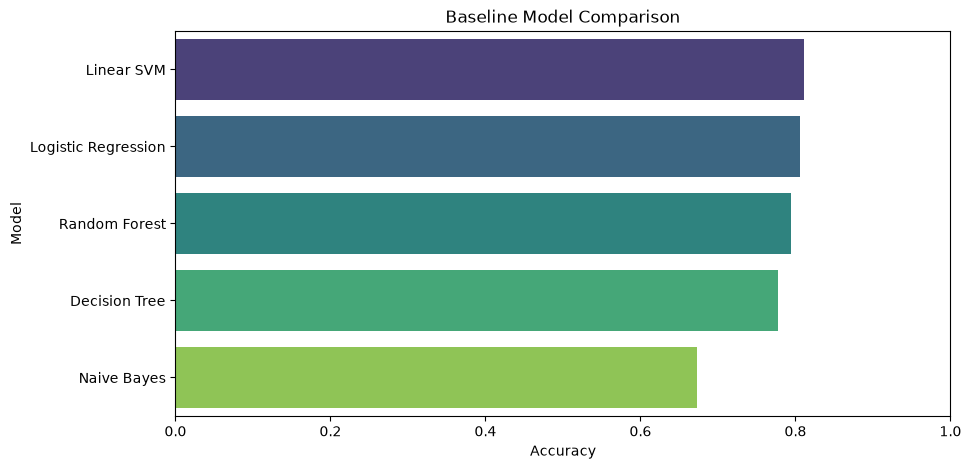

In [39]:
plt.figure(figsize=(10,5))
sns.barplot(
    x="Accuracy",
    y="Model",
    data=results_df,
    palette="viridis"
)
plt.title("Baseline Model Comparison")
plt.xlim(0,1)
plt.show()

# LSTM model 

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128
    )
)

model.add(
    Bidirectional(
        LSTM(64)
    )
)

model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))

model.add(Dropout(0.2))

model.add(Dense(num_classes, activation="softmax"))

model.build(input_shape=(None, max_length))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 42, 128)             │       5,363,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,471,371 (20.87 MB)

 Trainable params: 5,471,371 (20.87 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model.build(input_shape=(None, max_length))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 42, 128)             │       5,363,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,471,371 (20.87 MB)

 Trainable params: 5,471,371 (20.87 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
print("Vocabulary Size :", vocab_size)
print("Maximum Length :", max_length)
print("Number of Classes :", num_classes)

Vocabulary Size : 41903
Maximum Length : 42
Number of Classes : 11


In [43]:
from tensorflow.keras.optimizers import Adam
# Compile the LSTM model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled successfully!")

Model compiled successfully!


In [44]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
history = model.fit(
    X_train,
    y_train,
    epochs=25,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 151s 168ms/step - accuracy: 0.6099 - loss: 1.1964 - val_accuracy: 0.7828 - val_loss: 0.6985
Epoch 2/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 128s 158ms/step - accuracy: 0.8157 - loss: 0.6054 - val_accuracy: 0.8002 - val_loss: 0.6469
Epoch 3/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 130s 161ms/step - accuracy: 0.8498 - loss: 0.4872 - val_accuracy: 0.8024 - val_loss: 0.6658
Epoch 4/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 132s 163ms/step - accuracy: 0.8746 - loss: 0.4081 - val_accuracy: 0.8018 - val_loss: 0.6833
Epoch 5/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 133s 164ms/step - accuracy: 0.8951 - loss: 0.3507 - val_accuracy: 0.7951 - val_loss: 0.7469
Epoch 6/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 120s 148ms/step - accuracy: 0.9070 - loss: 0.3032 - val_accuracy: 0.7993 - val_loss: 0.7993
Epoch 7/25
809/809 ━━━━━━━━━━━━━━━━━━━━ 110s 136ms/step - accuracy: 0.9194 - loss: 0.2605 - val_accuracy: 0.7917 - val_loss: 0.8655


In [45]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("Accuracy:", accuracy * 100)

506/506 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8060 - loss: 0.6263
Loss: 0.6263267397880554
Accuracy: 80.60126304626465


In [46]:
import pickle

with open("tokenizer.pkl", "wb") as file:
    pickle.dump(tokenizer, file)

print("Tokenizer saved successfully!")

Tokenizer saved successfully!


In [47]:
import pickle

with open("label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)

print("Label Encoder saved successfully!")

Label Encoder saved successfully!


In [48]:
model.save("emotion_lstm_model.keras")

print("Model saved successfully!")

Model saved successfully!


In [49]:
print(df["emotion"].value_counts())

emotion
neutral       9907
sadness       9316
happiness     9155
love          8586
surprise      7915
anger         7465
relief        7279
fun           6240
hate          6206
enthusiasm    5250
empty         3507
Name: count, dtype: int64


In [50]:
print(history.history["accuracy"])
print(history.history["val_accuracy"])

[0.6098824739456177, 0.8157477378845215, 0.8497525453567505, 0.8745553493499756, 0.8950858116149902, 0.9070135951042175, 0.9193666577339172]
[0.7827869057655334, 0.8001855611801147, 0.8023507595062256, 0.8018094897270203, 0.7950819730758667, 0.7993350028991699, 0.7916795611381531]
